# 🔬 Embryo Stage Classification — 2-Phase Training v3
### MobileNetV2 · InceptionV3 · VGG16 · VGG19
### OrdinalFocal Loss · 2-Phase Transfer Learning (Warmup → Fine-Tune)

**Key design choices:**
- Phase 1: head-only warmup, higher LR, 5 epochs — fast stabilisation
- Phase 2: head + last 2 conv blocks, lower LR, 12-20 epochs — accuracy jump
- No full-network phase — too slow on T4 for VGG, marginal gains
- Per-model LR configs via `PHASE_CONFIG`
- CosineAnnealing LR schedule via `tf.keras.optimizers.schedules`
- CSV epoch logging + best-checkpoint saving by `val_loss`
- Learning curves with phase boundary visualisation
- Class rebalancing, class-weighted focal loss, label smoothing
- GAP+GMP pooling, smaller head, higher dropout

---
## Cell 1 — Imports & Seeds

In [1]:
import os, warnings, random, gc, csv
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, InceptionV3, VGG16, VGG19
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, mean_absolute_error
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print('TensorFlow :', tf.__version__)
print('GPUs       :', tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision: float16 enabled')

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision: float16 enabled


---
## Cell 2 — Paths & Config (2-Phase v3)

In [13]:
DATA_ROOT  = Path('/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset')
ANN_DIR    = DATA_ROOT / 'embryo_dataset_annotations' / 'embryo_dataset_annotations'
DATA_DIR   = DATA_ROOT / 'embryo_dataset' / 'embryo_dataset'
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(exist_ok=True)

CFG = dict(
    BATCH_SIZE     = 32,
    # Image sizes
    IMG_SIZE       = 224,
    INCEPTION_SIZE = 299,
    # Head architecture — smaller + more regularised
    DROPOUT1       = 0.60,
    DROPOUT2       = 0.50,
    FC1            = 256,
    FC2            = 128,
    # Loss params
    LAMBDA_CE      = 0.6,
    LAMBDA_ORD     = 0.4,
    FOCAL_GAMMA    = 2.0,
    LABEL_SMOOTHING= 0.1,
    # Anti-overfitting: class rebalancing
    SAMPLE_CAP     = 15000,
    MIN_SAMPLES    = 500,
    MAX_CW         = 10.0,
    # Data splits
    TEST_SPLIT     = 0.15,
    VAL_SPLIT      = 0.15,
    SEED           = 42,
    MIN_FILE_BYTES = 1024,
)

# ── Per-model 2-phase schedule ──────────────────────────────────────────────────
#              p1_epochs  p1_lr    p2_epochs  p2_lr
PHASE_CONFIG = {
    'MobileNetV2': (5,    1e-4,    20,       5e-5),   # already done
    'VGG16':       (5,    1e-4,    7,        1e-5),   # ← change
    'VGG19':       (5,    1e-4,    7,        1e-5),   # ← change
    'InceptionV3': (5,    1e-4,    7,        5e-5),   # ← change
}


BATCH_SIZE = CFG['BATCH_SIZE']

for name, (p1e, p1lr, p2e, p2lr) in PHASE_CONFIG.items():
    print(f'{name:>12s}  Phase1: {p1e}ep @ LR={p1lr}  |  Phase2: {p2e}ep @ LR={p2lr}  |  Total: {p1e+p2e}ep')

 MobileNetV2  Phase1: 5ep @ LR=0.0001  |  Phase2: 20ep @ LR=5e-05  |  Total: 25ep
       VGG16  Phase1: 5ep @ LR=0.0001  |  Phase2: 7ep @ LR=1e-05  |  Total: 12ep
       VGG19  Phase1: 5ep @ LR=0.0001  |  Phase2: 7ep @ LR=1e-05  |  Total: 12ep
 InceptionV3  Phase1: 5ep @ LR=0.0001  |  Phase2: 7ep @ LR=5e-05  |  Total: 12ep


---
## Cell 3 — Phase Definitions & Ordinal Structures

In [3]:
PHASES_ORDERED = [
    'pPB2', 'pPNa', 'pPNf',
    'p2','p3','p4','p5','p6','p7','p8','p9+',
    'pM', 'pSB', 'pB', 'pEB', 'pHB',
]
N_CLASSES   = len(PHASES_ORDERED)
NUM_CLASSES = N_CLASSES

ANN_KEY_MAP = {
    'tPB2':'pPB2','tPNa':'pPNa','tPNf':'pPNf',
    't2':'p2','t3':'p3','t4':'p4','t5':'p5',
    't6':'p6','t7':'p7','t8':'p8','t9+':'p9+',
    'tM':'pM','tSB':'pSB','tB':'pB','tEB':'pEB','tHB':'pHB',
}
PHASE2IDX = {p: i for i, p in enumerate(PHASES_ORDERED)}
IDX2PHASE = {i: p for p, i in PHASE2IDX.items()}

_r = np.arange(N_CLASSES, dtype=np.float32)
RANK_MATRIX_TF = tf.constant((_r[:, None] - _r[None, :]) ** 2)
RANK_MATRIX_TF = RANK_MATRIX_TF / tf.reduce_max(RANK_MATRIX_TF)

print(f'Number of classes : {N_CLASSES}')
print(f'Phases            : {PHASES_ORDERED}')

Number of classes : 16
Phases            : ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']


---
## Cell 4 — Data Utilities

In [4]:
def build_run_index(video_dir):
    run_map = {}
    for f in video_dir.iterdir():
        if f.suffix.lower() != '.jpeg':
            continue
        idx = f.stem.rfind('_RUN')
        if idx == -1:
            continue
        try:
            run_map[int(f.stem[idx + 4:])] = f
        except ValueError:
            continue
    return run_map


def is_valid_jpeg(path, min_bytes=CFG['MIN_FILE_BYTES']):
    try:
        if os.path.getsize(path) < min_bytes:
            return False
        with open(path, 'rb') as fh:
            if fh.read(2) != b'\xff\xd8':
                return False
            fh.seek(-2, 2)
            return fh.read(2) == b'\xff\xd9'
    except (OSError, IOError):
        return False


def parse_csv(csv_path):
    try:
        df = pd.read_csv(csv_path, header=None,
                         names=['phase_key', 'start', 'end'],
                         sep=',', dtype=str)
        df = df.dropna()
        df['phase_key'] = df['phase_key'].str.strip()
        df['start'] = pd.to_numeric(df['start'], errors='coerce')
        df['end']   = pd.to_numeric(df['end'],   errors='coerce')
        df = df.dropna()
        df['start'] = df['start'].astype(int)
        df['end']   = df['end'].astype(int)
        return df.values.tolist()
    except Exception as e:
        print(f'  [CSV parse error] {csv_path.name}: {e}')
        return []


print('Data utility functions defined.')

Data utility functions defined.


---
## Cell 5 — Build Frame-Level DataFrame

In [5]:
def build_dataframe(ann_dir, data_dir):
    csv_files = sorted(ann_dir.glob('*_phases.csv'))
    print(f'Annotation CSVs found : {len(csv_files)}')
    records = []
    skipped_novid = skipped_badann = skipped_nofile = skipped_corrupt = 0

    for csv_path in csv_files:
        video_id  = csv_path.stem.replace('_phases', '')
        video_dir = data_dir / video_id
        if not video_dir.is_dir():
            skipped_novid += 1; continue
        rows = parse_csv(csv_path)
        if not rows:
            skipped_badann += 1; continue
        run_map = build_run_index(video_dir)
        if not run_map:
            skipped_novid += 1; continue

        frame_label = {}
        for row in rows:
            phase_lbl = ANN_KEY_MAP.get(str(row[0]).strip())
            if phase_lbl is None:
                continue
            label_idx = PHASE2IDX[phase_lbl]
            for fi in range(int(row[1]), int(row[2]) + 1):
                frame_label[fi] = label_idx
        if not frame_label:
            skipped_badann += 1; continue

        for frame_idx, label_idx in frame_label.items():
            img_file = run_map.get(frame_idx)
            if img_file is None:
                skipped_nofile += 1; continue
            img_path = str(img_file)
            if not is_valid_jpeg(img_path):
                skipped_corrupt += 1; continue
            records.append({
                'img_path'  : img_path,
                'label'     : label_idx,
                'phase_idx' : label_idx,
                'phase'     : IDX2PHASE[label_idx],
                'video_id'  : video_id,
            })

    df = pd.DataFrame(records)
    print(f'Total valid frames    : {len(df):,}')
    print(f'Skipped (no folder)   : {skipped_novid}')
    print(f'Skipped (bad CSV)     : {skipped_badann}')
    print(f'Skipped (no img file) : {skipped_nofile}')
    print(f'Skipped (corrupt)     : {skipped_corrupt}')
    if not df.empty:
        print(f'\nPhase distribution:\n{df["phase"].value_counts().to_string()}\n')
    return df


print('Building frame-level dataframe ...')
df = build_dataframe(ANN_DIR, DATA_DIR)

if df.empty:
    raise RuntimeError('No valid frames found. Check ANN_DIR / DATA_DIR paths.')

Building frame-level dataframe ...
Annotation CSVs found : 704
Total valid frames    : 271,636
Skipped (no folder)   : 0
Skipped (bad CSV)     : 0
Skipped (no img file) : 4706
Skipped (corrupt)     : 25792

Phase distribution:
phase
p9+     46420
pPNa    39652
p8      29805
p4      27246
p2      27134
pEB     19353
pM      15468
pSB     15232
p7       9843
pPB2     8253
p6       7799
pB       7391
p5       7080
pPNf     6333
p3       4530
pHB        97



---
## Cell 6 — Train / Val / Test Split + Class Rebalancing + Weights

In [7]:
video_ids = df['video_id'].unique()
train_vids, test_vids = train_test_split(
    video_ids, test_size=CFG['TEST_SPLIT'], random_state=CFG['SEED'])
val_frac = CFG['VAL_SPLIT'] / (1.0 - CFG['TEST_SPLIT'])
train_vids, val_vids = train_test_split(
    train_vids, test_size=val_frac, random_state=CFG['SEED'])

df_train = df[df['video_id'].isin(train_vids)].reset_index(drop=True)
df_val   = df[df['video_id'].isin(val_vids)].reset_index(drop=True)
df_test  = df[df['video_id'].isin(test_vids)].reset_index(drop=True)

print(f'Split  ->  train: {len(df_train):,}  val: {len(df_val):,}  test: {len(df_test):,}')
print(f'Videos ->  train: {len(train_vids)}   val: {len(val_vids)}   test: {len(test_vids)}')

# ── Rebalance training set ─────────────────────────────────────────────────────
print(f'\n--- Class Rebalancing (cap={CFG["SAMPLE_CAP"]}, min={CFG["MIN_SAMPLES"]}) ---')
print(f'Before rebalancing: {len(df_train):,} samples')

resampled = []
for cls in range(N_CLASSES):
    cls_df = df_train[df_train['label'] == cls]
    n_orig = len(cls_df)
    if n_orig > CFG['SAMPLE_CAP']:
        cls_df = cls_df.sample(n=CFG['SAMPLE_CAP'], random_state=CFG['SEED'])
        tag = '(capped)'
    elif n_orig < CFG['MIN_SAMPLES']:
        extra = cls_df.sample(n=CFG['MIN_SAMPLES'] - n_orig,
                              replace=True, random_state=CFG['SEED'])
        cls_df = pd.concat([cls_df, extra])
        tag = '(oversampled)'
    else:
        tag = '(kept)'
    print(f'  {PHASES_ORDERED[cls]:>5s}  {n_orig:>6,} -> {len(cls_df):>6,}  {tag}')
    resampled.append(cls_df)

df_train = pd.concat(resampled).sample(
    frac=1.0, random_state=CFG['SEED']).reset_index(drop=True)
print(f'After rebalancing : {len(df_train):,} samples')

# ── Class weights (clipped) ────────────────────────────────────────────────────
counts  = Counter(df_train['label'].tolist())
total   = sum(counts.values())
cw_dict = {
    i: total / (N_CLASSES * counts[i]) if i in counts else 1.0
    for i in range(N_CLASSES)
}
class_weights_array = np.array([cw_dict[i] for i in range(N_CLASSES)], dtype=np.float32)
class_weights_array = np.clip(class_weights_array, 0.3, CFG['MAX_CW'])

print(f'\nClass weights (clipped to [0.3, {CFG["MAX_CW"]}]):')
for i, w in enumerate(class_weights_array):
    print(f'  {PHASES_ORDERED[i]:>5s}  weight={w:.3f}  n={counts.get(i, 0):,}')

Split  ->  train: 190,297  val: 40,604  test: 40,735
Videos ->  train: 456   val: 98   test: 98

--- Class Rebalancing (cap=15000, min=500) ---
Before rebalancing: 190,297 samples
   pPB2   5,945 ->  5,945  (kept)
   pPNa  27,835 -> 15,000  (capped)
   pPNf   4,368 ->  4,368  (kept)
     p2  18,806 -> 15,000  (capped)
     p3   3,121 ->  3,121  (kept)
     p4  18,871 -> 15,000  (capped)
     p5   4,635 ->  4,635  (kept)
     p6   5,517 ->  5,517  (kept)
     p7   6,467 ->  6,467  (kept)
     p8  21,114 -> 15,000  (capped)
    p9+  33,272 -> 15,000  (capped)
     pM  10,879 -> 10,879  (kept)
    pSB  10,463 -> 10,463  (kept)
     pB   5,526 ->  5,526  (kept)
    pEB  13,412 -> 13,412  (kept)
    pHB      66 ->    500  (oversampled)
After rebalancing : 145,833 samples

Class weights (clipped to [0.3, 10.0]):
   pPB2  weight=1.533  n=5,945
   pPNa  weight=0.608  n=15,000
   pPNf  weight=2.087  n=4,368
     p2  weight=0.608  n=15,000
     p3  weight=2.920  n=3,121
     p4  weight=0.608  n=

---
## Cell 7 — OrdinalFocalWeightedLoss

In [8]:
class OrdinalFocalWeightedLoss(keras.losses.Loss):
    """
    L = lambda_ce * L_focal_weighted + lambda_ord * L_ord
    
    Components:
      - Focal CE with class weights: cw[y] * (1-pt)^gamma * CE_smooth
      - Ordinal penalty: sum(probs * rank_distance_matrix)
    """
    def __init__(self, class_weights_arr,
                 lambda_ce=0.6, lambda_ord=0.4,
                 gamma=2.0, label_smoothing=0.1,
                 name="ordinal_focal_loss", **kwargs):
        super().__init__(name=name)
        if isinstance(class_weights_arr, tf.Tensor):
            class_weights_arr = class_weights_arr.numpy()
        self.class_weights_arr = np.array(class_weights_arr, dtype=np.float32)
        self.cw = tf.constant(self.class_weights_arr, dtype=tf.float32)
        self.lambda_ce = float(lambda_ce)
        self.lambda_ord = float(lambda_ord)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def call(self, y_true, y_logits):
        y_logits = tf.cast(y_logits, tf.float32)
        y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        probs    = tf.nn.softmax(y_logits, axis=-1)
        y_onehot = tf.one_hot(y_true, N_CLASSES, dtype=tf.float32)
        y_smooth = y_onehot * (1.0 - self.label_smoothing) + \
                   self.label_smoothing / tf.cast(N_CLASSES, tf.float32)
        pt = tf.reduce_sum(probs * y_onehot, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)
        sample_weights = tf.gather(self.cw, y_true)
        log_probs = tf.nn.log_softmax(y_logits, axis=-1)
        ce = -tf.reduce_sum(y_smooth * log_probs, axis=-1)
        L_focal = tf.reduce_mean(sample_weights * focal_weight * ce)
        rank_costs = tf.gather(RANK_MATRIX_TF, y_true)
        L_ord = tf.reduce_mean(tf.reduce_sum(probs * rank_costs, axis=-1))

        return self.lambda_ce * L_focal + self.lambda_ord * L_ord

    def get_config(self):
        config = super().get_config()
        config.update({
            'class_weights_arr': self.class_weights_arr.tolist(),
            'lambda_ce': self.lambda_ce,
            'lambda_ord': self.lambda_ord,
            'gamma': self.gamma,
            'label_smoothing': self.label_smoothing,
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = config.copy()
        config['class_weights_arr'] = np.array(config['class_weights_arr'], dtype=np.float32)
        return cls(**config)

print('Loss defined: focal + class-weighted + label-smoothed + ordinal.')

Loss defined: focal + class-weighted + label-smoothed + ordinal.


---
## Cell 8 — tf.data Pipeline · Model Factory · Unfreeze

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

PREPROCESS_FN = {
    'VGG19':       vgg_preprocess,
    'VGG16':       vgg_preprocess,
    'MobileNetV2': mobilenet_preprocess,
    'InceptionV3': inception_preprocess,
}
MODEL_CONFIGS = {
    'VGG19':       {'target_size': CFG['IMG_SIZE'],       'backbone': VGG19},
    'VGG16':       {'target_size': CFG['IMG_SIZE'],       'backbone': VGG16},
    'MobileNetV2': {'target_size': CFG['IMG_SIZE'],       'backbone': MobileNetV2},
    'InceptionV3': {'target_size': CFG['INCEPTION_SIZE'], 'backbone': InceptionV3},
}


# ── tf.data pipeline (enhanced augmentation) ──────────────────────────────────
def make_dataset(df_split, target_size, preprocess_fn,
                 batch_size, augment_data=False, shuffle=True):

    paths  = df_split['img_path'].values.tolist()
    labels = df_split['label'].values.astype(np.int32)
    ds     = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=1, dct_method='INTEGER_ACCURATE')
        img = tf.image.grayscale_to_rgb(img)
        img = tf.image.resize(img, [target_size, target_size])
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img, label

    # Cutout / random erasing (50% probability)
    def _cutout(img):
        pad = int(target_size * 0.125)
        def _apply():
            cy = tf.random.uniform([], pad, target_size - pad, dtype=tf.int32)
            cx = tf.random.uniform([], pad, target_size - pad, dtype=tf.int32)
            yr = tf.range(target_size)
            xr = tf.range(target_size)
            ym = tf.cast(tf.math.logical_and(yr >= cy - pad, yr < cy + pad), tf.float32)
            xm = tf.cast(tf.math.logical_and(xr >= cx - pad, xr < cx + pad), tf.float32)
            mask = 1.0 - tf.tensordot(ym, xm, axes=0)
            return img * tf.expand_dims(mask, -1)
        return tf.cond(tf.random.uniform([]) < 0.5, _apply, lambda: img)

    # Enhanced augmentation — pure tf.image ops
    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.25)
        img = tf.image.random_contrast(img, 0.70, 1.30)
        # Random 90-degree rotations
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        # Random crop (85%)
        crop_size = tf.cast(tf.cast(target_size, tf.float32) * 0.85, tf.int32)
        img = tf.image.random_crop(img, [crop_size, crop_size, 3])
        img = tf.image.resize(img, [target_size, target_size])
        # Cutout
        img = _cutout(img)
        return img, label

    if shuffle:
        ds = ds.shuffle(min(len(df_split), 10_000),
                        seed=CFG['SEED'], reshuffle_each_iteration=True)
    ds = ds.map(load, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


# ── Model factory (GAP+GMP, smaller head) ─────────────────────────────────────
def build_model(model_name):
    cfg      = MODEL_CONFIGS[model_name]
    tsize    = cfg['target_size']
    backbone = cfg['backbone']

    inp  = keras.Input(shape=(tsize, tsize, 3), name='input')
    base = backbone(include_top=False, weights='imagenet', input_tensor=inp)
    base.trainable = False

    # GAP + GMP concatenation
    gap = layers.GlobalAveragePooling2D()(base.output)
    gmp = layers.GlobalMaxPooling2D()(base.output)
    x   = layers.Concatenate()([gap, gmp])

    x = layers.Dense(CFG['FC1'], activation='relu',
                     kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG['DROPOUT1'])(x)

    x = layers.Dense(CFG['FC2'], activation='relu',
                     kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG['DROPOUT2'])(x)

    out = layers.Dense(N_CLASSES, dtype='float32', name='logits')(x)
    return Model(inputs=inp, outputs=out, name=model_name)


# ── Unfreeze last 2 conv blocks ───────────────────────────────────────────────
def _get_backbone_layers(model, model_name):
    """Get backbone layers — handles both nested and flattened cases."""
    name_map = {'MobileNetV2': 'mobilenetv2', 'InceptionV3': 'inception_v3',
                'VGG16': 'vgg16', 'VGG19': 'vgg19'}
    target = name_map.get(model_name, model_name.lower())
    # Case 1: backbone is a nested Model layer
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and target in layer.name.lower():
            print(f'  Found nested base: {layer.name} ({len(layer.layers)} layers)')
            return layer.layers
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and len(layer.layers) > 1:
            print(f'  Found nested base: {layer.name} ({len(layer.layers)} layers)')
            return layer.layers
    # Case 2: layers are flattened into the main model (MobileNetV2)
    print(f'  Base flattened — using model.layers directly ({len(model.layers)} layers)')
    return model.layers

def unfreeze_top_blocks(model, model_name):
    """Unfreeze the last 2 conv blocks for Phase 2 fine-tuning."""
    backbone_layers = _get_backbone_layers(model, model_name)

    if model_name == 'MobileNetV2':
        for layer in backbone_layers: layer.trainable = False
        for layer in backbone_layers[-30:]: layer.trainable = True
        print('  MobileNetV2: unfroze last 30 layers')
    elif model_name == 'InceptionV3':
        unfreeze = False
        for layer in backbone_layers:
            if layer.name == 'mixed7': unfreeze = True
            layer.trainable = unfreeze
        print('  InceptionV3: unfroze from mixed7 onward')
    elif model_name in ('VGG16', 'VGG19'):
        for layer in backbone_layers:
            layer.trainable = ('block4' in layer.name or 'block5' in layer.name)
        print(f'  {model_name}: unfroze block4 + block5')
    else:
        raise ValueError(f'Unknown model: {model_name}')

    # Always keep head layers trainable
    for layer in model.layers:
        if any(k in layer.name for k in ['dense', 'batch_norm', 'dropout', 'logits',
                                          'concatenate', 'global_average', 'global_max']):
            layer.trainable = True

    n = sum(1 for l in model.layers if l.trainable)
    print(f'  Trainable layers: {n} / {len(model.layers)}')


print('Pipeline, model factory, and unfreeze defined.')

Pipeline, model factory, and unfreeze defined.


---
## Cell 9 — Cosine Annealing LR Schedule

In [10]:
class CosineAnnealingSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Cosine annealing from initial_lr to eta_min over total_steps."""
    def __init__(self, initial_lr, total_steps, eta_min=None):
        super().__init__()
        self.initial_lr = float(initial_lr)
        self.total_steps = float(total_steps)
        self.eta_min = float(eta_min if eta_min is not None else initial_lr / 100.0)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        cos_val = tf.cos(np.pi * step / self.total_steps)
        return self.eta_min + 0.5 * (self.initial_lr - self.eta_min) * (1.0 + cos_val)

    def get_config(self):
        return {
            'initial_lr': self.initial_lr,
            'total_steps': self.total_steps,
            'eta_min': self.eta_min,
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

print('CosineAnnealingSchedule defined.')

CosineAnnealingSchedule defined.


---
## Cell 10 — `run_phase()` + `train_model()` — 2-Phase Training

**Phase 1**: head only, higher LR, 5 epochs — fast stabilisation  
**Phase 2**: head + last 2 conv blocks, lower LR, 12-20 epochs — accuracy jump  
No full-network phase — too slow on T4 for VGG, marginal gains anyway.

In [11]:
# ── Per-epoch training step (manual loop for CSV logging) ─────────────────────
def run_phase(model, model_name, ds_train, ds_val, custom_loss,
              lr, epochs, phase_label, best_val_loss, save_path, epoch_csv):
    """
    Run one training phase with cosine annealing LR.
    Logs per-epoch metrics to CSV. Saves best model by val_loss.
    Returns: best_val_loss, train_losses, val_losses, val_accs, val_f1s
    """
    steps_per_epoch = tf.data.experimental.cardinality(ds_train).numpy()
    if steps_per_epoch < 0:  # cardinality unknown, estimate
        steps_per_epoch = len(df_train) // BATCH_SIZE + 1
    total_steps = steps_per_epoch * epochs

    lr_schedule = CosineAnnealingSchedule(
        initial_lr=lr, total_steps=total_steps, eta_min=lr / 100.0
    )

    model.compile(
        optimizer=Adam(learning_rate=lr_schedule, clipnorm=1.0),
        loss=custom_loss,
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

    csv_fields = ['phase', 'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1']
    losses_tr, train_accs_list, losses_val, accs, f1s = [], [], [], [], []

    for ep in range(1, epochs + 1):
        print(f'\n── {phase_label}  Epoch {ep}/{epochs} ──')

        # Train one epoch
        history = model.fit(ds_train, epochs=1, verbose=1)
        tr_loss = history.history['loss'][0]
        tr_acc  = history.history['accuracy'][0]

        # Validate
        val_results = model.evaluate(ds_val, verbose=0)
        val_loss = val_results[0]
        val_acc  = val_results[1]

        # Compute F1 score on validation set
        y_pred_logits = model.predict(ds_val, verbose=0)
        y_pred_cls    = np.argmax(y_pred_logits, axis=1)
        y_true_cls    = df_val['label'].values
        val_f1 = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)

        losses_tr.append(tr_loss)
        train_accs_list.append(tr_acc)
        losses_val.append(val_loss)
        accs.append(val_acc)
        f1s.append(val_f1)

        # Log to CSV
        with open(epoch_csv, 'a', newline='') as f:
            csv.DictWriter(f, fieldnames=csv_fields).writerow({
                'phase':      phase_label, 'epoch': ep,
                'train_loss': round(tr_loss, 6),
                'train_acc':  round(tr_acc,  6),
                'val_loss':   round(val_loss, 6),
                'val_acc':    round(val_acc, 6),
                'val_f1':     round(val_f1, 6),
            })

        tag = '  <- saved' if val_loss < best_val_loss else ''
        print(f'  tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.4f} | '
              f'val_loss {val_loss:.4f} | val_acc {val_acc:.4f} | F1 {val_f1:.4f}{tag}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            model.save(save_path)
            print(f'  Checkpoint saved: {save_path}')

    return best_val_loss, losses_tr, losses_val, accs, f1s


# ── Main 2-phase train_model ──────────────────────────────────────────────────
def train_model(model_name):
    print(f"\n{'='*60}\n  {model_name.upper()}\n{'='*60}")
    p1_ep, p1_lr, p2_ep, p2_lr = PHASE_CONFIG[model_name]

    tsize         = MODEL_CONFIGS[model_name]['target_size']
    preprocess_fn = PREPROCESS_FN[model_name]

    ds_train = make_dataset(df_train, tsize, preprocess_fn,
                            BATCH_SIZE, augment_data=True,  shuffle=True)
    ds_val   = make_dataset(df_val,   tsize, preprocess_fn,
                            BATCH_SIZE, augment_data=False, shuffle=False)
    ds_test  = make_dataset(df_test,  tsize, preprocess_fn,
                            BATCH_SIZE, augment_data=False, shuffle=False)

    model = build_model(model_name)

    custom_loss = OrdinalFocalWeightedLoss(
        class_weights_arr=class_weights_array,
        lambda_ce=CFG['LAMBDA_CE'],
        lambda_ord=CFG['LAMBDA_ORD'],
        gamma=CFG['FOCAL_GAMMA'],
        label_smoothing=CFG['LABEL_SMOOTHING'],
    )

    save_path = str(OUTPUT_DIR / f'best_{model_name}.keras')
    epoch_csv = str(OUTPUT_DIR / f'{model_name}_epoch_log.csv')
    with open(epoch_csv, 'w', newline='') as f:
        csv.DictWriter(
            f, fieldnames=['phase','epoch','train_loss','train_acc','val_loss','val_acc','val_f1']
        ).writeheader()

    # ── Phase 1: head only ──
    print(f'\nPHASE 1 — head only  ({p1_ep} epochs, lr={p1_lr})')
    best_val_loss, tr1, val1, acc1, f1_1 = run_phase(
        model, model_name, ds_train, ds_val, custom_loss,
        p1_lr, p1_ep, 'warmup', float('inf'), save_path, epoch_csv
    )

    # ── Phase 2: head + last 2 blocks ──
    print(f'\nPHASE 2 — head + last 2 blocks  ({p2_ep} epochs, lr={p2_lr})')
    unfreeze_top_blocks(model, model_name)
    best_val_loss, tr2, val2, acc2, f1_2 = run_phase(
        model, model_name, ds_train, ds_val, custom_loss,
        p2_lr, p2_ep, 'finetune', best_val_loss, save_path, epoch_csv
    )

    # ── Test on best checkpoint ──
    print(f'\nLoading best checkpoint (val_loss={best_val_loss:.4f})...')
    best_model = keras.models.load_model(
        save_path,
        custom_objects={'OrdinalFocalWeightedLoss': OrdinalFocalWeightedLoss,
                        'CosineAnnealingSchedule': CosineAnnealingSchedule},
        compile=False,
    )
    best_model.compile(
        loss=custom_loss,
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

    test_results = best_model.evaluate(ds_test, verbose=1)
    test_loss, test_acc = test_results[0], test_results[1]
    test_top3 = test_results[2] if len(test_results) > 2 else 0.0

    y_pred_logits = best_model.predict(ds_test, verbose=1)
    y_pred_cls    = np.argmax(y_pred_logits, axis=1)
    y_true_cls    = df_test['phase_idx'].values
    test_f1  = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
    mae_score = float(mean_absolute_error(y_true_cls, y_pred_cls))

    print(f'\nTEST — acc: {test_acc:.4f}  F1: {test_f1:.4f}  MAE: {mae_score:.3f}')

    # Classification report
    present = sorted(set(y_true_cls.tolist()))
    names   = [PHASES_ORDERED[i] for i in present]
    report_str = classification_report(
        y_true_cls, y_pred_cls,
        labels=present, target_names=names,
        zero_division=0
    )
    print(report_str)

    with open(str(OUTPUT_DIR / f'{model_name}_test_report.txt'), 'w') as f:
        f.write(f'Model: {model_name}\n')
        f.write(f'Test Acc   : {test_acc:.6f}\n')
        f.write(f'Test F1    : {test_f1:.6f}\n')
        f.write(f'Test MAE   : {mae_score:.6f}\n\n')
        f.write(report_str)

    # Confusion matrix
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=present)
    fig_cm, ax_cm = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names,
                ax=ax_cm, annot_kws={'size': 7})
    ax_cm.set_title(f'{model_name} Confusion Matrix')
    ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'{model_name}_confusion.png'), dpi=120)
    plt.close(fig_cm)
    print(f'  Saved -> {model_name}_confusion.png')

    # ── Learning curves ──
    all_tr  = tr1  + tr2
    all_val = val1 + val2
    all_acc = acc1 + acc2
    all_f1  = f1_1 + f1_2
    ep_range   = range(1, len(all_tr) + 1)
    phase_line = p1_ep + 0.5

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{model_name.upper()}  |  Phase boundary at epoch {p1_ep}→{p1_ep+1}',
                 fontsize=11)
    for ax in axes:
        ax.axvline(phase_line, color='gray', linestyle='--', alpha=0.6, label='unfreeze')
    axes[0].plot(ep_range, all_tr,  label='train')
    axes[0].plot(ep_range, all_val, label='val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(ep_range, all_acc, color='tab:green')
    axes[1].set_title('Val Accuracy')
    axes[2].plot(ep_range, all_f1,  color='tab:orange')
    axes[2].set_title('Val F1')
    for ax in axes:
        ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'{model_name}_curves.png'), dpi=120)
    plt.show()
    plt.close(fig)

    # Clean up
    del best_model
    gc.collect()

    return {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'test_top3': test_top3,
        'test_f1': test_f1,
        'test_mae': mae_score,
        'y_pred': y_pred_cls,
        'y_true': y_true_cls,
        'train_losses': all_tr,
        'val_losses': all_val,
        'val_accs': all_acc,
        'val_f1s': all_f1,
    }


results = {}
print('2-phase training functions defined. Run Cells 11–14 to train each model.')

2-phase training functions defined. Run Cells 11–14 to train each model.


---
## Cell 11 — Train VGG19

In [14]:
try:
    results['VGG19'] = train_model('VGG19')
except Exception as e:
    print(f'ERROR in VGG19: {e}')
    import traceback; traceback.print_exc()

gc.collect()
print('Memory cleared. Ready for next model.')


  VGG19
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

PHASE 1 — head only  (5 epochs, lr=0.0001)

── warmup  Epoch 1/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 374s 79ms/step - accuracy: 0.1671 - loss: 1.7087 - top3_acc: 0.4085
  tr_loss 1.3998 | tr_acc 0.2206 | val_loss 0.9099 | val_acc 0.3554 | F1 0.2698  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── warmup  Epoch 2/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 348s 76ms/step - accuracy: 0.2977 - loss: 1.0286 - top3_acc: 0.6626
  tr_loss 0.9909 | tr_acc 0.3084 | val_loss 0.8136 | val_acc 0.3894 | F1 0.2952  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── warmup  Epoch 3/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 348s 76ms/step - accuracy: 0.3355 - loss: 0.9149 - top3_acc: 0.7095
  tr_loss 0.9010 | tr_acc 0.3398 | val_loss 0.7787 | val_acc 0.4170 | F1 0.3132  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── warmup  Epoch 4/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 357s 78ms/step - accuracy: 0.3537 - los

2026-04-08 08:10:39.384897: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.9 = (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,28,28,512]{3,2,1,0} %bitcast.15201, f16[32,28,28,512]{3,2,1,0} %bitcast.15226), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/VGG19_1/block4_conv2_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-08 08:10:44.527653: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.142857334s
Trying 

4558/4558 ━━━━━━━━━━━━━━━━━━━━ 547s 114ms/step - accuracy: 0.4431 - loss: 0.7234 - top3_acc: 0.8180
  tr_loss 0.6711 | tr_acc 0.4750 | val_loss 0.7487 | val_acc 0.4535 | F1 0.3414  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── finetune  Epoch 2/7 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 525s 115ms/step - accuracy: 0.5293 - loss: 0.5871 - top3_acc: 0.8828
  tr_loss 0.5704 | tr_acc 0.5423 | val_loss 0.6297 | val_acc 0.5233 | F1 0.4071  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── finetune  Epoch 3/7 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 522s 115ms/step - accuracy: 0.5685 - loss: 0.5300 - top3_acc: 0.9037
  tr_loss 0.5192 | tr_acc 0.5750 | val_loss 0.6246 | val_acc 0.5285 | F1 0.4204  <- saved
  Checkpoint saved: /kaggle/working/best_VGG19.keras

── finetune  Epoch 4/7 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 526s 115ms/step - accuracy: 0.5954 - loss: 0.4918 - top3_acc: 0.9153
  tr_loss 0.4852 | tr_acc 0.6005 | val_loss 0.6917 | val_acc 0.4800 | F1 0.3679

── finetu

---
## Cell 12 — Train VGG16

In [16]:
try:
    results['VGG16'] = train_model('VGG16')
except Exception as e:
    print(f'ERROR in VGG16: {e}')
    import traceback; traceback.print_exc()

gc.collect()
print('Memory cleared. Ready for next model.')


  VGG16

PHASE 1 — head only  (5 epochs, lr=0.0001)

── warmup  Epoch 1/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 363s 78ms/step - accuracy: 0.1673 - loss: 1.7085 - top3_acc: 0.4046
  tr_loss 1.4039 | tr_acc 0.2187 | val_loss 0.8555 | val_acc 0.3760 | F1 0.2791  <- saved
  Checkpoint saved: /kaggle/working/best_VGG16.keras

── warmup  Epoch 2/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 340s 75ms/step - accuracy: 0.2985 - loss: 1.0298 - top3_acc: 0.6596
  tr_loss 0.9900 | tr_acc 0.3117 | val_loss 0.7843 | val_acc 0.4138 | F1 0.3127  <- saved
  Checkpoint saved: /kaggle/working/best_VGG16.keras

── warmup  Epoch 3/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 334s 73ms/step - accuracy: 0.3391 - loss: 0.9115 - top3_acc: 0.7106
  tr_loss 0.9003 | tr_acc 0.3430 | val_loss 0.7697 | val_acc 0.4155 | F1 0.3194  <- saved
  Checkpoint saved: /kaggle/working/best_VGG16.keras

── warmup  Epoch 4/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 347s 76ms/step - accuracy: 0.3552 - loss: 0.8723 - top3_acc: 0.7254
  tr_loss 0.8679 | tr_

---
## Cell 13 — Train MobileNetV2

In [12]:
try:
    results['MobileNetV2'] = train_model('MobileNetV2')
except Exception as e:
    print(f'ERROR in MobileNetV2: {e}')
    import traceback; traceback.print_exc()

gc.collect()
print('Memory cleared. Ready for next model.')


  MOBILENETV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

PHASE 1 — head only  (5 epochs, lr=0.0001)

── warmup  Epoch 1/5 ──


I0000 00:00:1775623255.091675      97 service.cc:152] XLA service 0x7c55500127b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775623255.091733      97 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775623255.091737      97 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775623256.791288      97 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775623276.667156      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4558/4558 ━━━━━━━━━━━━━━━━━━━━ 341s 66ms/step - accuracy: 0.1874 - loss: 1.6631 - top3_acc: 0.4369
  tr_loss 1.3697 | tr_acc 0.2383 | val_loss 0.9111 | val_acc 0.3185 | F1 0.2427  <- saved
  Checkpoint saved: /kaggle/working/best_MobileNetV2.keras

── warmup  Epoch 2/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 265s 58ms/step - accuracy: 0.3071 - loss: 1.0288 - top3_acc: 0.6632
  tr_loss 0.9876 | tr_acc 0.3185 | val_loss 0.8513 | val_acc 0.3532 | F1 0.2668  <- saved
  Checkpoint saved: /kaggle/working/best_MobileNetV2.keras

── warmup  Epoch 3/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 267s 59ms/step - accuracy: 0.3465 - loss: 0.9028 - top3_acc: 0.7092
  tr_loss 0.8897 | tr_acc 0.3512 | val_loss 0.8396 | val_acc 0.3525 | F1 0.2773  <- saved
  Checkpoint saved: /kaggle/working/best_MobileNetV2.keras

── warmup  Epoch 4/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 267s 59ms/step - accuracy: 0.3644 - loss: 0.8601 - top3_acc: 0.7285
  tr_loss 0.8514 | tr_acc 0.3662 | val_loss 0.8231 | val_acc 0.3687 | F1 0.2912  <

---
## Cell 14 — Train InceptionV3

In [17]:
try:
    results['InceptionV3'] = train_model('InceptionV3')
except Exception as e:
    print(f'ERROR in InceptionV3: {e}')
    import traceback; traceback.print_exc()

gc.collect()
print('All models trained.')


  INCEPTIONV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

PHASE 1 — head only  (5 epochs, lr=0.0001)

── warmup  Epoch 1/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 412s 85ms/step - accuracy: 0.1908 - loss: 1.6100 - top3_acc: 0.4492
  tr_loss 1.3443 | tr_acc 0.2355 | val_loss 0.7623 | val_acc 0.4352 | F1 0.3265  <- saved
  Checkpoint saved: /kaggle/working/best_InceptionV3.keras

── warmup  Epoch 2/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 356s 78ms/step - accuracy: 0.3040 - loss: 1.0115 - top3_acc: 0.6689
  tr_loss 0.9751 | tr_acc 0.3150 | val_loss 0.7347 | val_acc 0.4418 | F1 0.3530  <- saved
  Checkpoint saved: /kaggle/working/best_InceptionV3.keras

── warmup  Epoch 3/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 367s 80ms/step - accuracy: 0.3450 - loss: 0.8888 - top3_acc: 0.7173
  tr_loss 0.8735 | tr_acc 0.3517 | val_loss 0.7120 | val_acc 0.4624 | F1 0.3616  <- saved
  Checkpoint saved: /kaggle/working/best_InceptionV3.keras

── warmup  Epoch 4/5 ──
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 385s 84ms/step 

---
## Cell 15 — Final Comparison Table & Plots

In [18]:
trained_names = list(results.keys())
n_models      = len(trained_names)

if n_models == 0:
    print('No results yet.')
else:
    # ── Comparison table ──
    rows = []
    for name in trained_names:
        r = results[name]
        rows.append({'model': name,
                     'top1_acc':    round(r['test_acc'], 4),
                     'top3_acc':    round(r['test_top3'], 4),
                     'macro_f1':    round(r['test_f1'], 4),
                     'ordinal_mae': round(r['test_mae'], 4)})
    results_df = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
    print('\n' + '='*60)
    print('  FINAL COMPARISON')
    print('='*60)
    print(results_df.to_string(index=False))
    results_df.to_csv(str(OUTPUT_DIR / 'comparison_results.csv'), index=False)

    # ── Comparison bar chart ──
    colors = ['#4878CF', '#D65F5F', '#6ACC65', '#B47CC7']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (col, title) in zip(axes, [
        ('top1_acc', 'Top-1 Accuracy'), ('top3_acc', 'Top-3 Accuracy'),
        ('macro_f1', 'Macro F1'), ('ordinal_mae', 'Ordinal MAE'),
    ]):
        bars = ax.bar(results_df['model'], results_df[col],
                      color=colors[:len(results_df)])
        ax.set_title(title, fontweight='bold')
        for bar, v in zip(bars, results_df[col]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle('Model Comparison (2-Phase Training v3)', fontsize=13)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'model_comparison.png'), dpi=120)
    plt.close(fig)
    print('Saved -> model_comparison.png')
    best = results_df.iloc[0]['model']
    print(f'\nBest model by Macro F1: {best}')
    print('All outputs saved to /kaggle/working/')


  FINAL COMPARISON
      model  top1_acc  top3_acc  macro_f1  ordinal_mae
      VGG16    0.5518    0.8812    0.4477       0.7361
InceptionV3    0.4806    0.8332    0.3963       0.9033
      VGG19    0.5036    0.8682    0.3954       0.7870
MobileNetV2    0.4538    0.8183    0.3651       1.0151
Saved -> model_comparison.png

Best model by Macro F1: VGG16
All outputs saved to /kaggle/working/



── Training Curves (All Models) ──


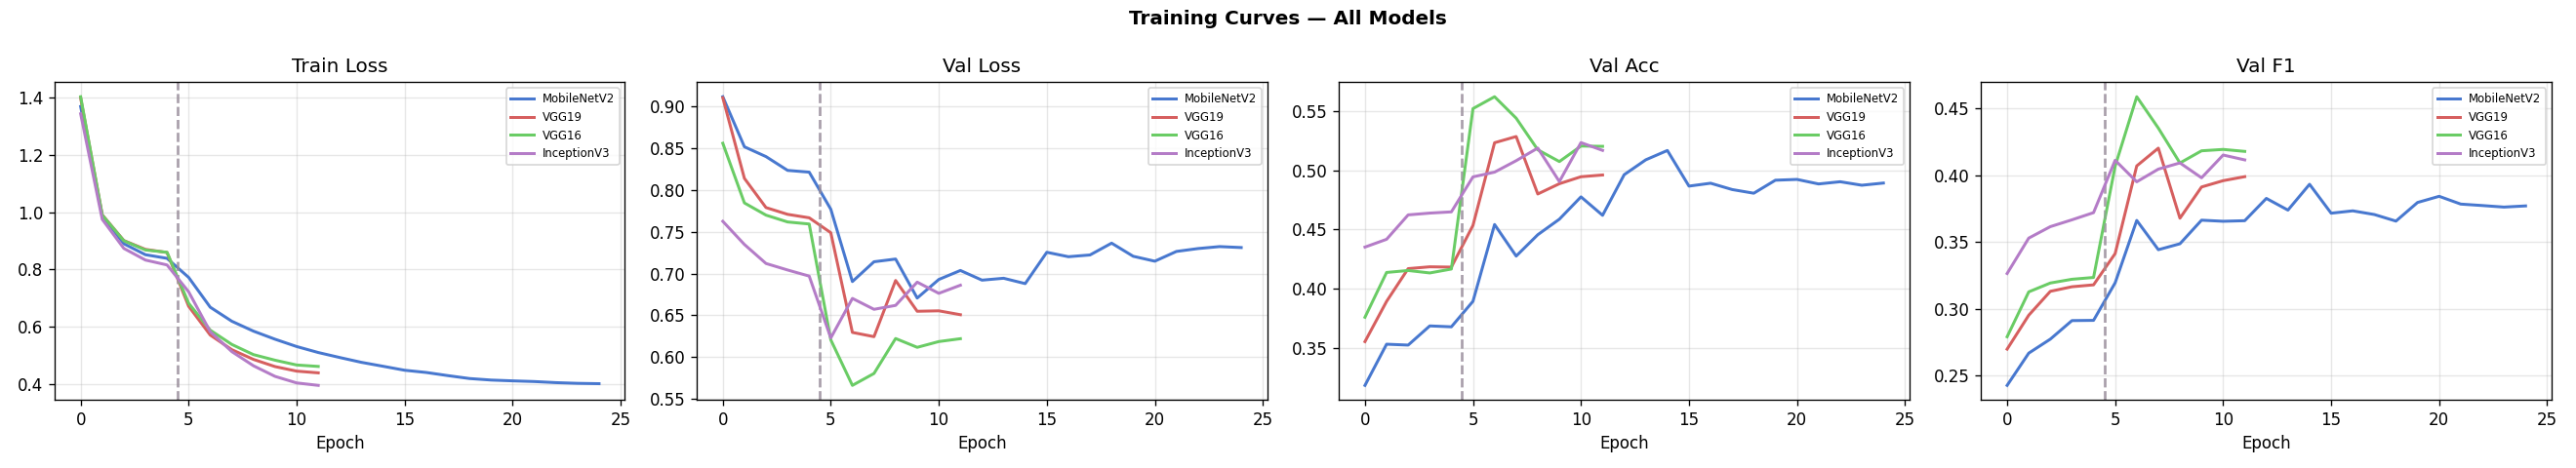


── Model Comparison (Bar Chart) ──


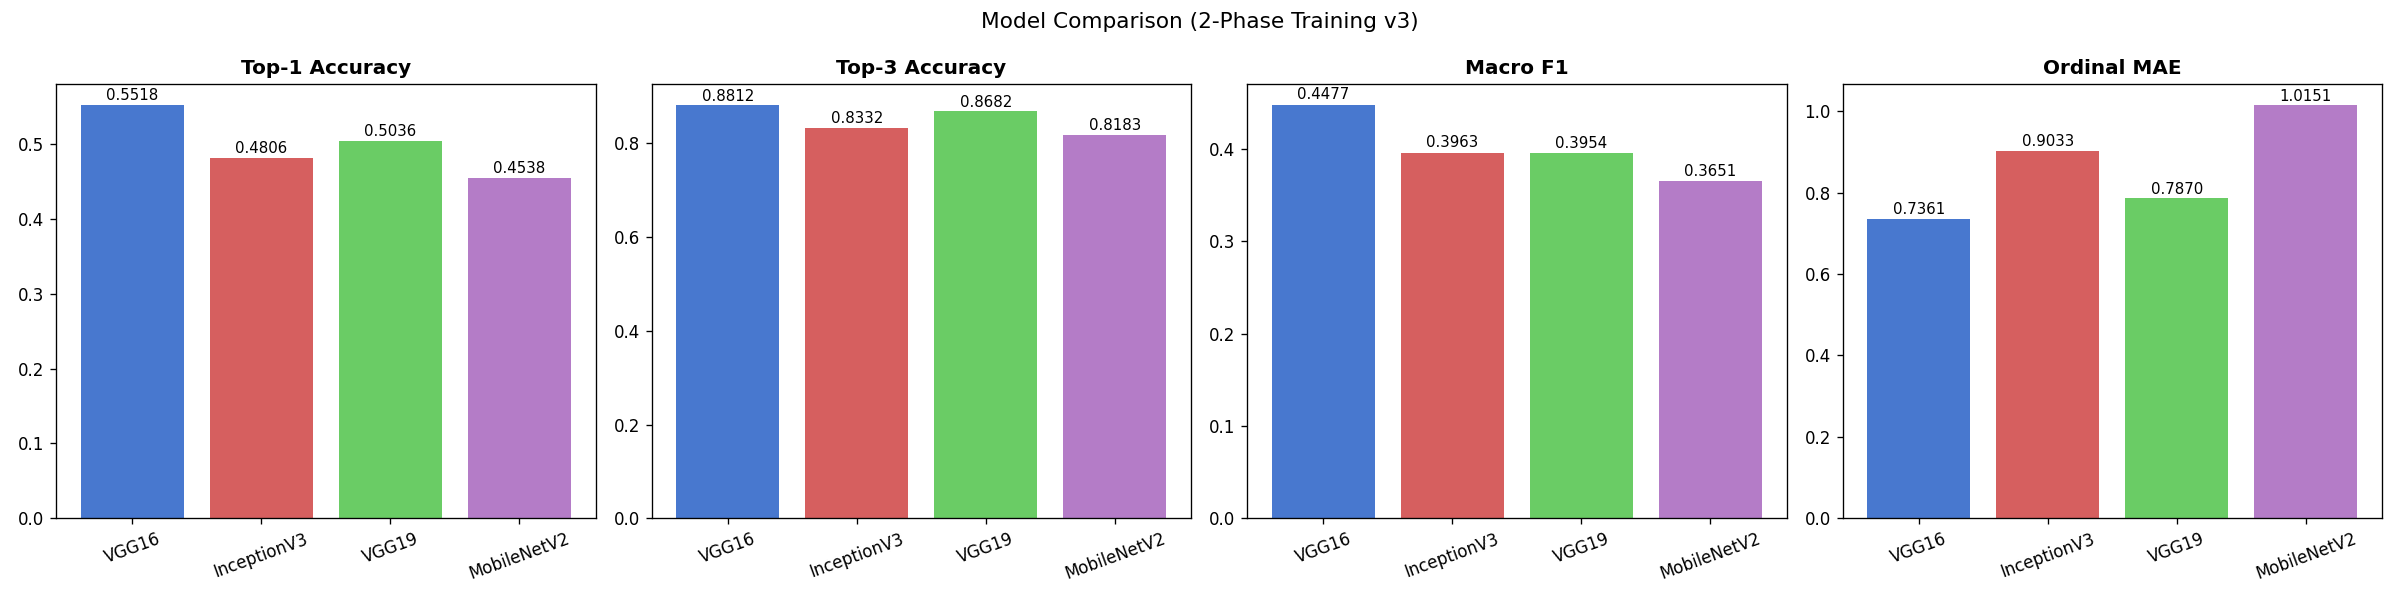


── MobileNetV2 — Confusion Matrix ──


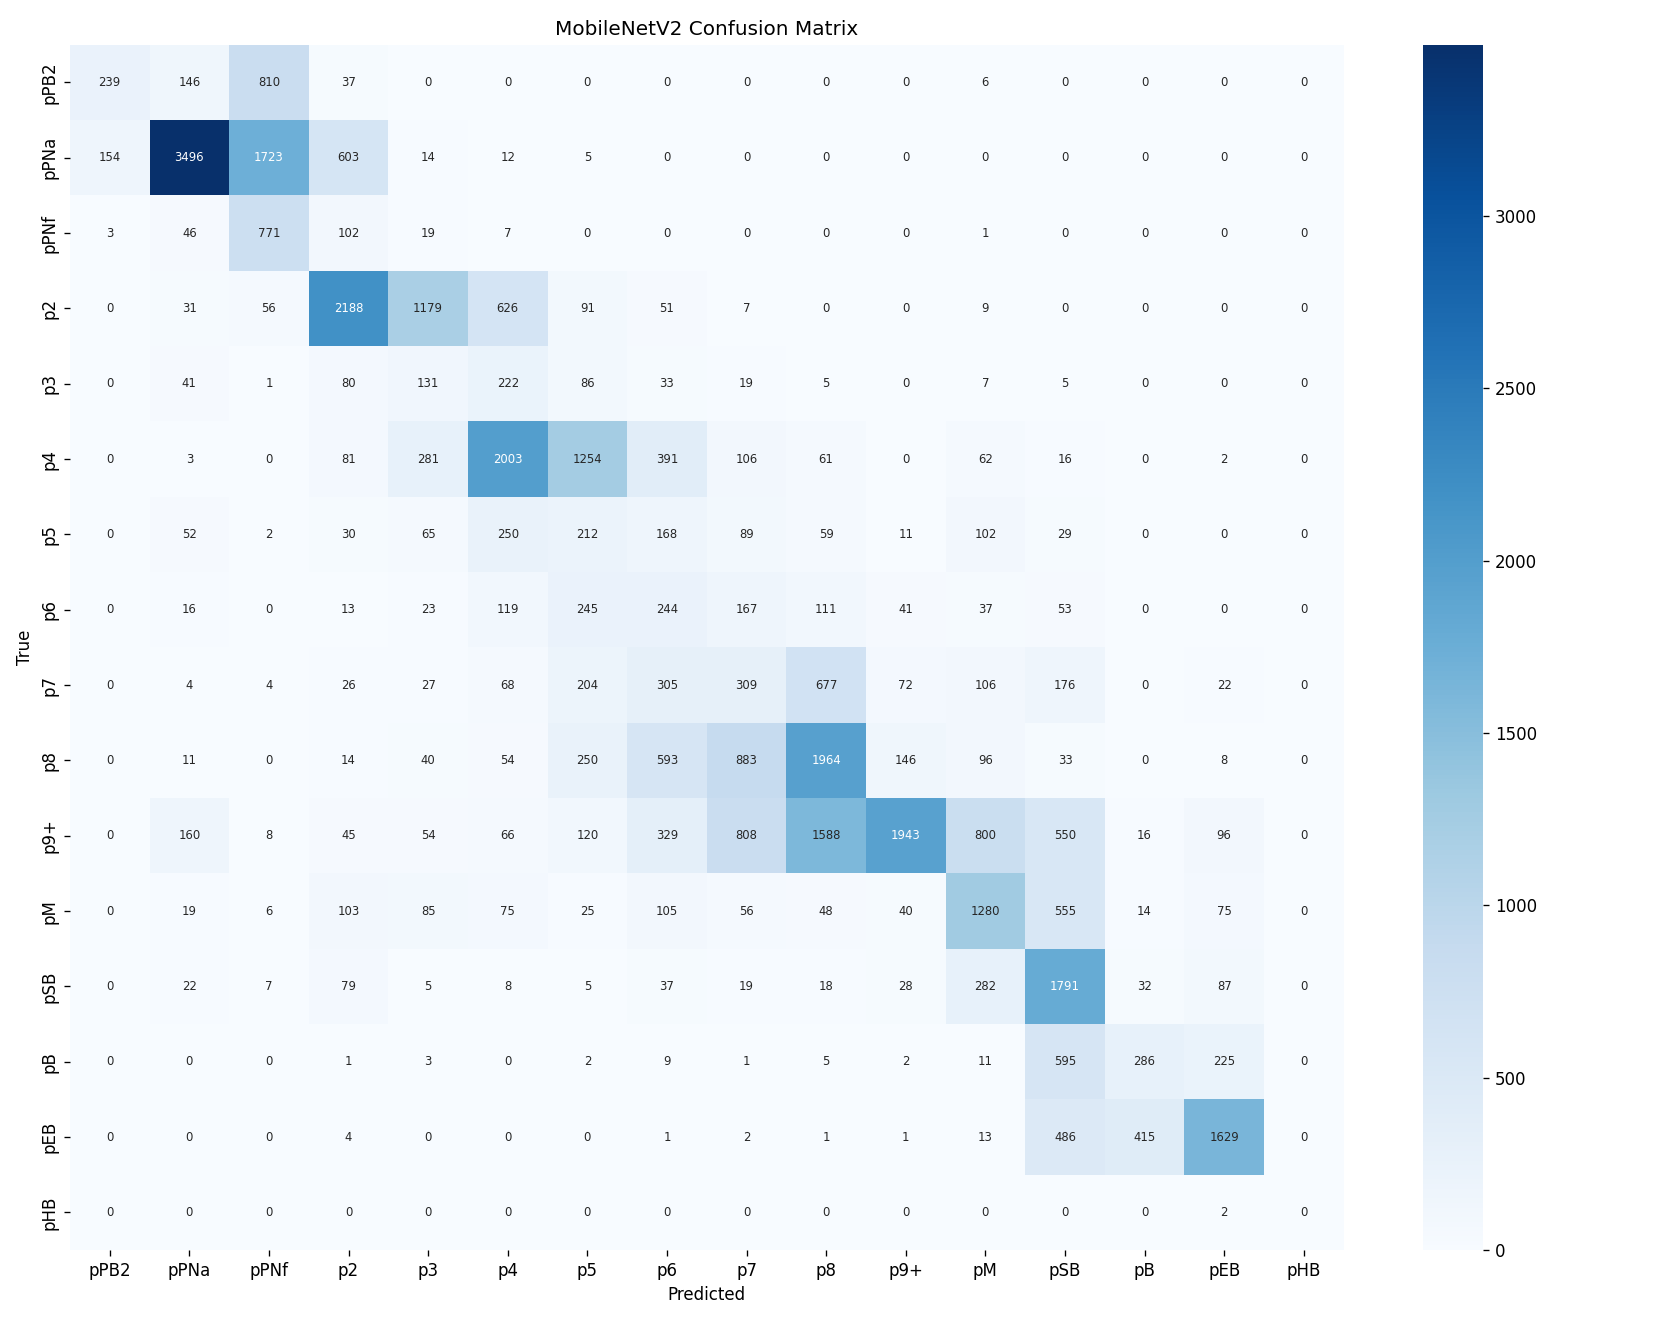


── MobileNetV2 — Learning Curves ──


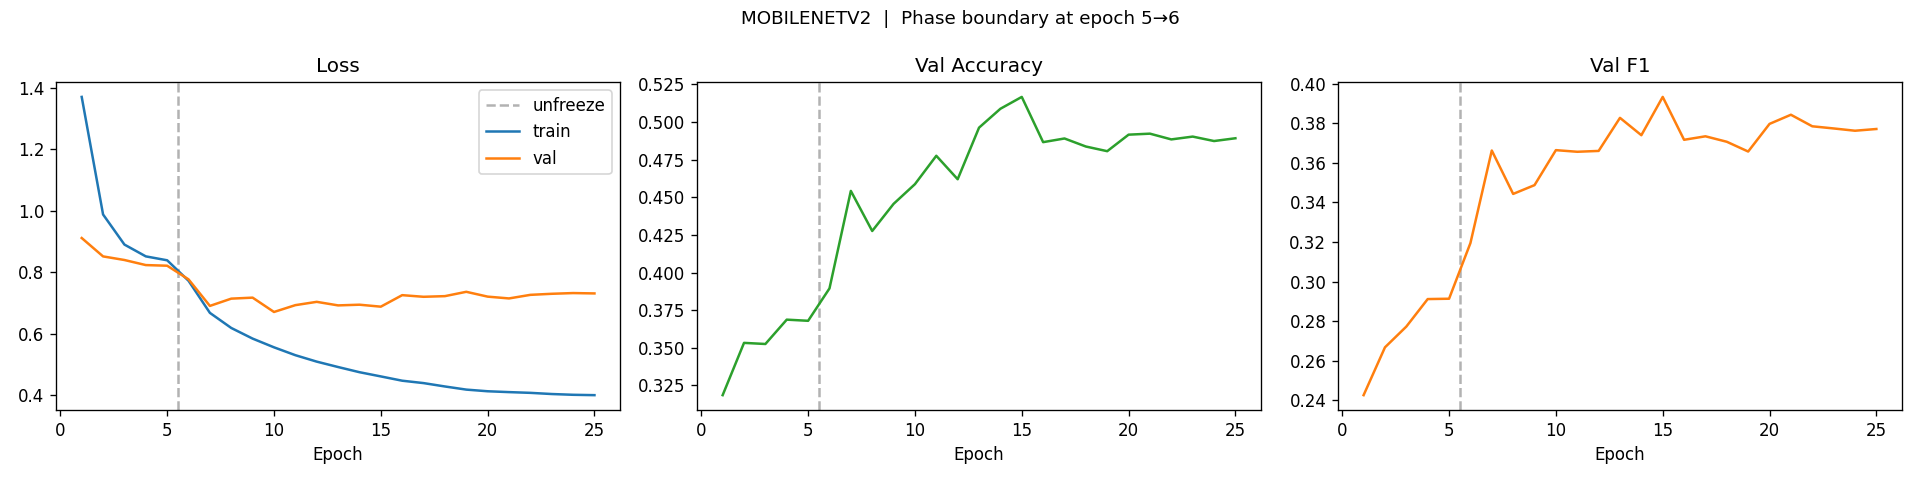


── VGG19 — Confusion Matrix ──


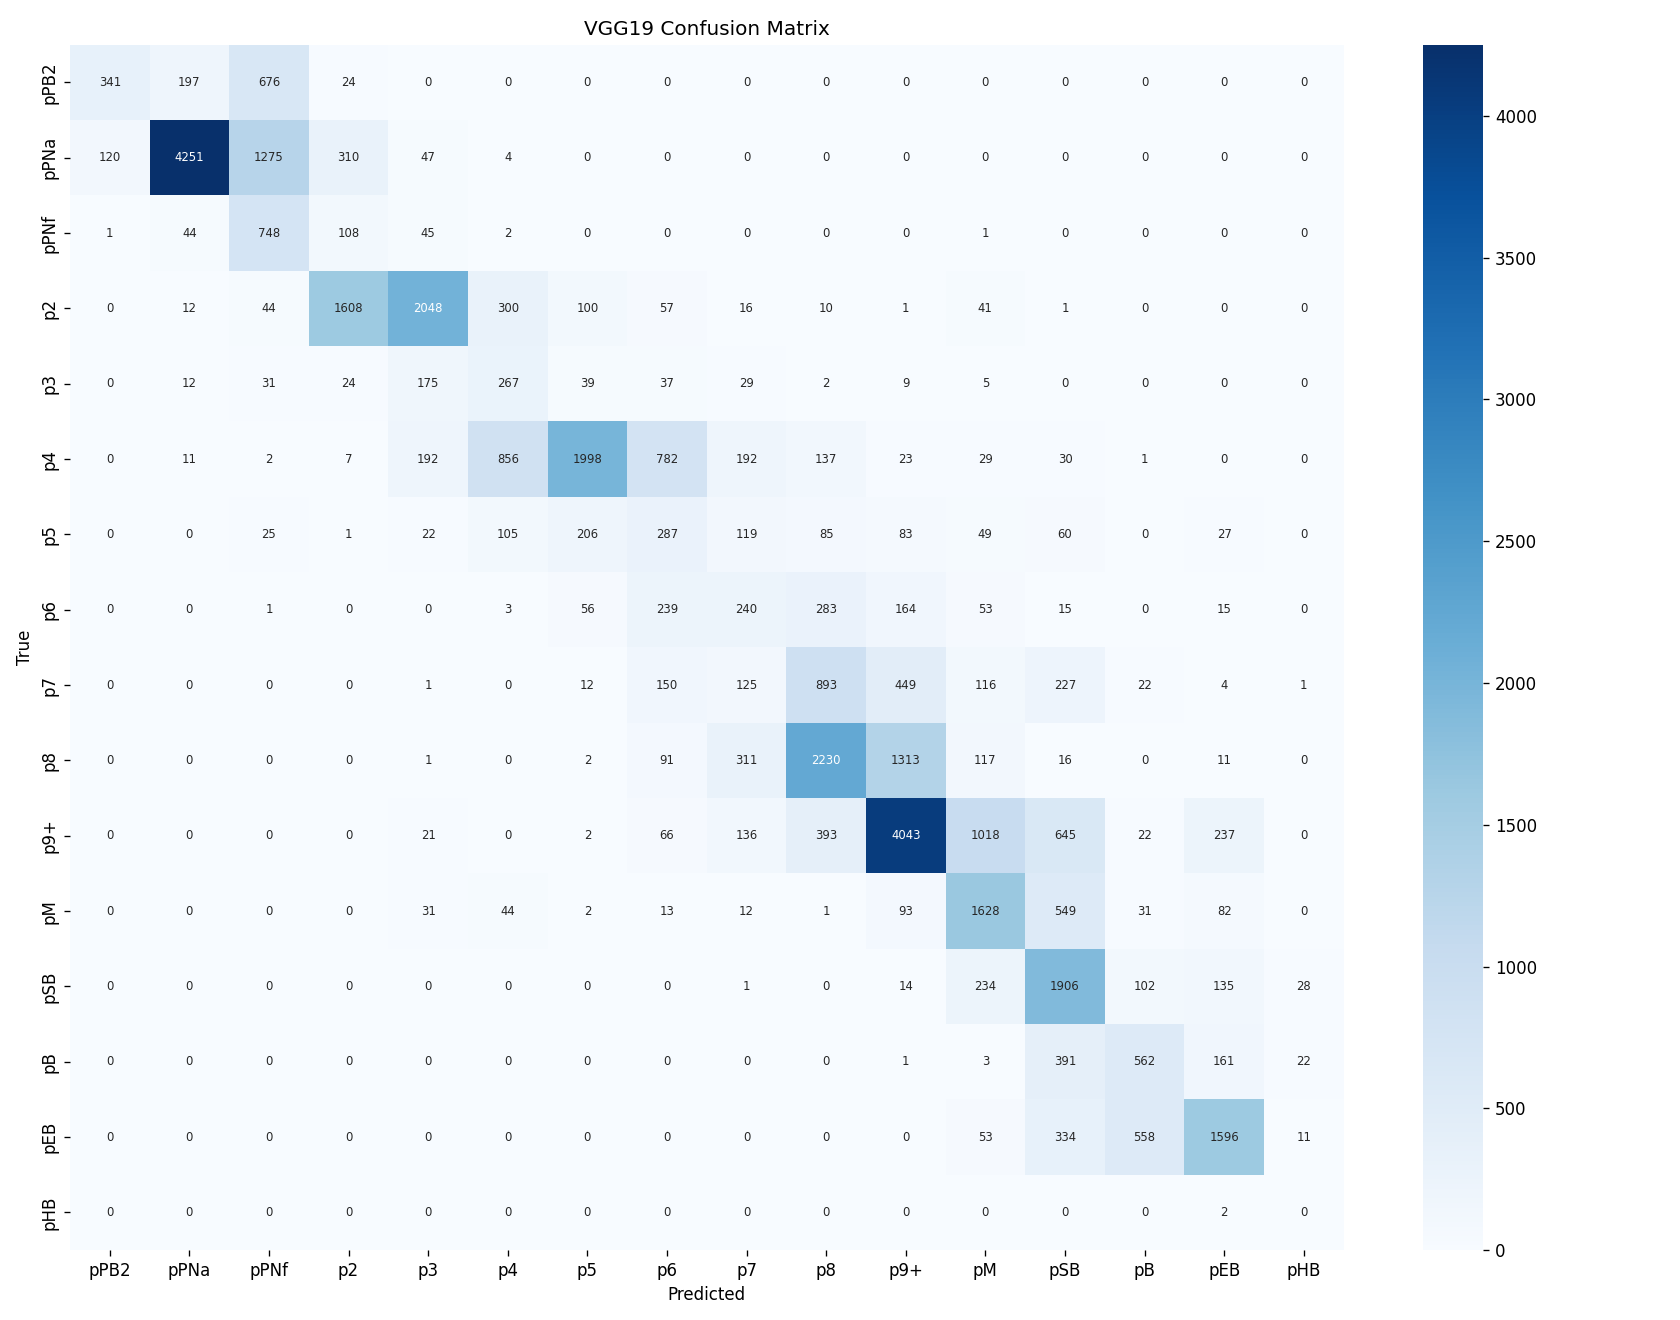


── VGG19 — Learning Curves ──


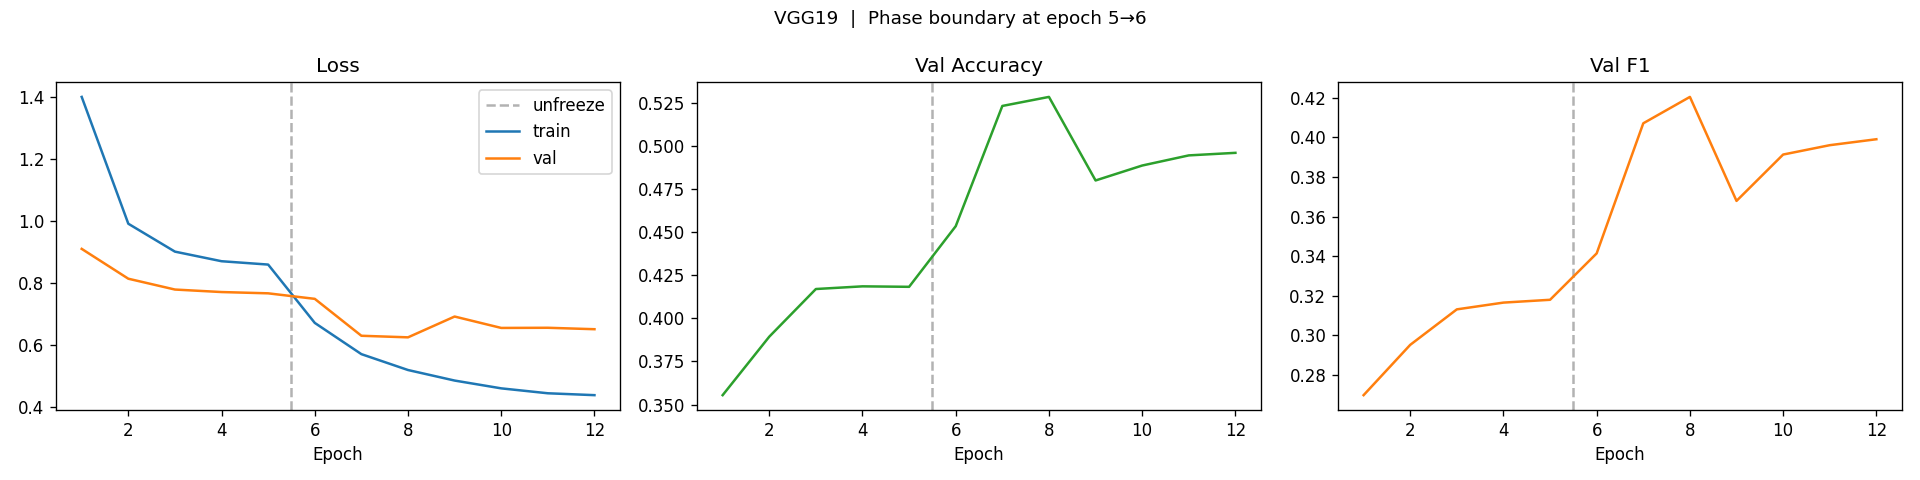


── VGG16 — Confusion Matrix ──


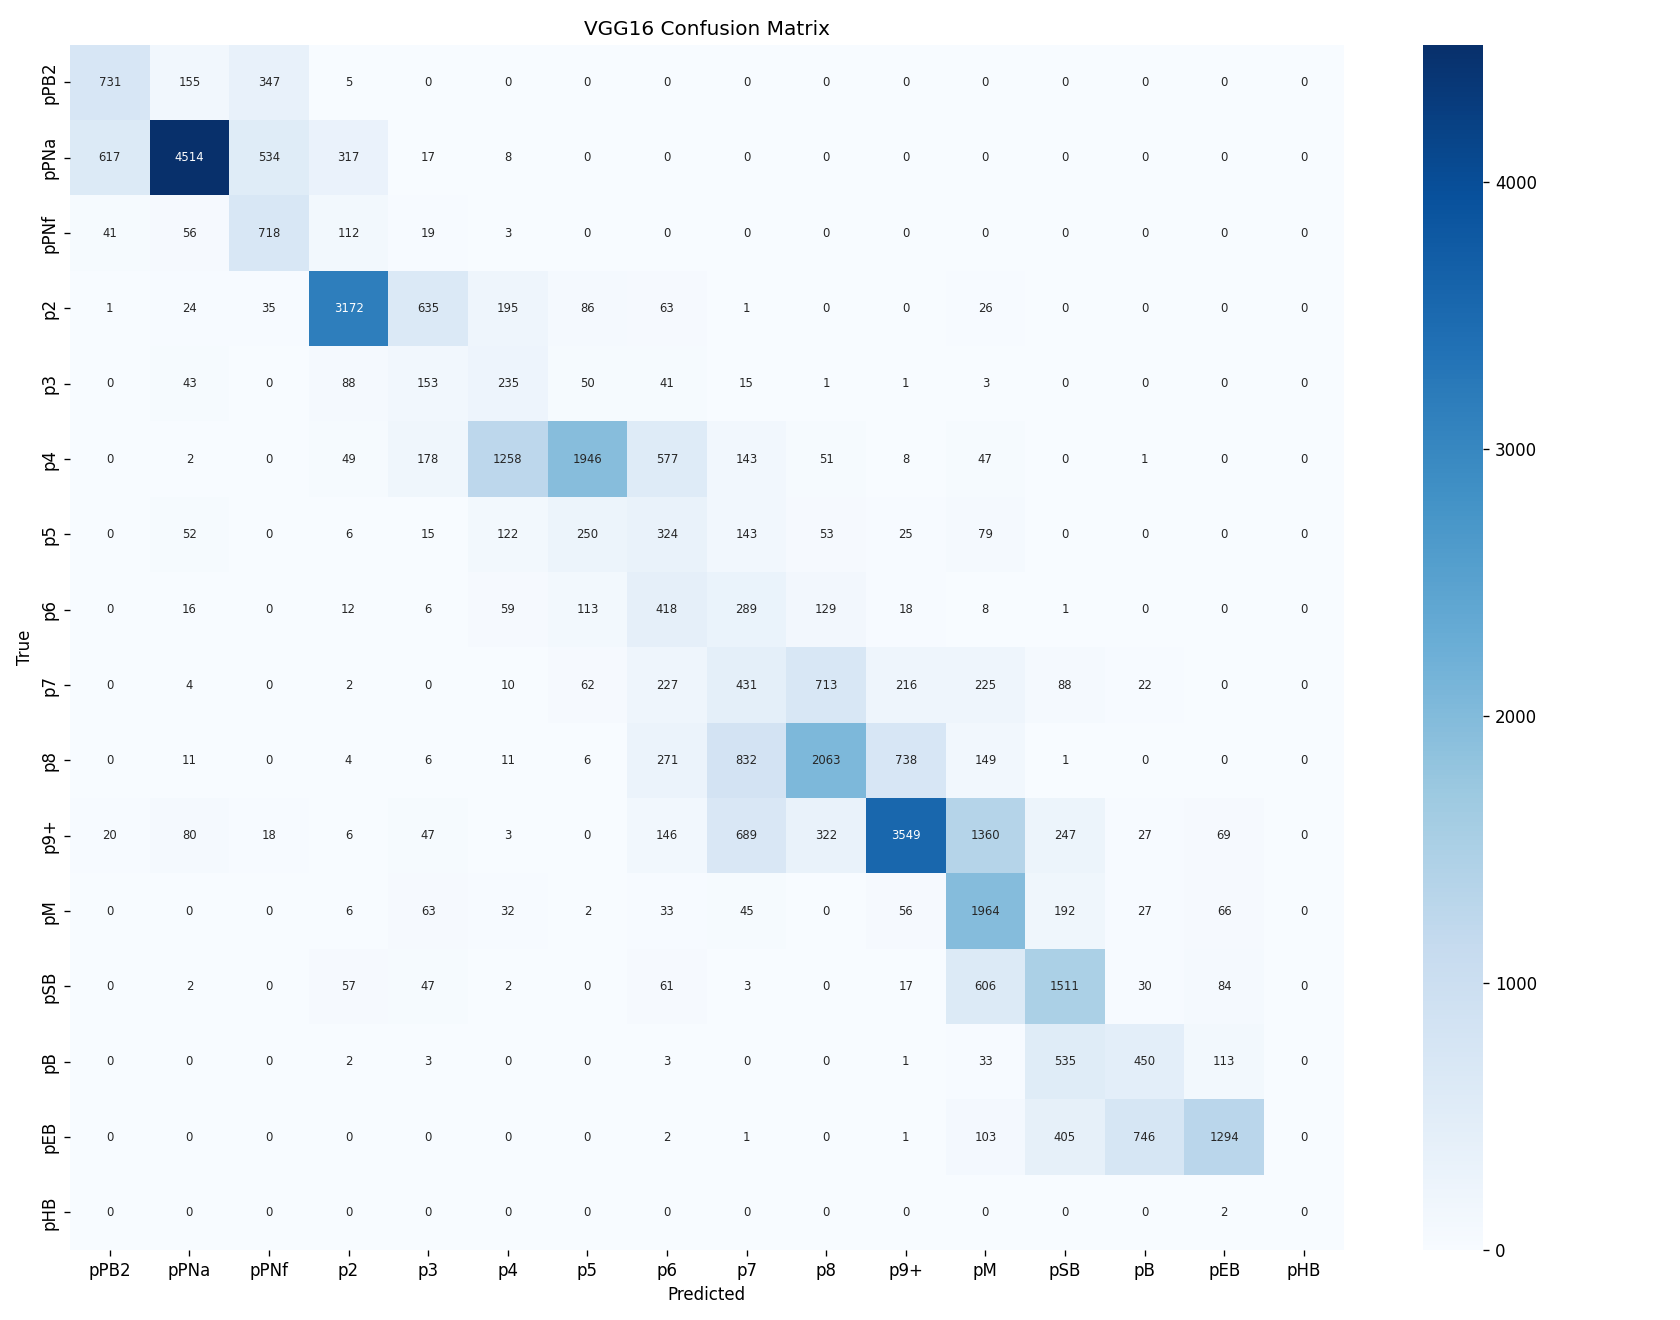


── VGG16 — Learning Curves ──


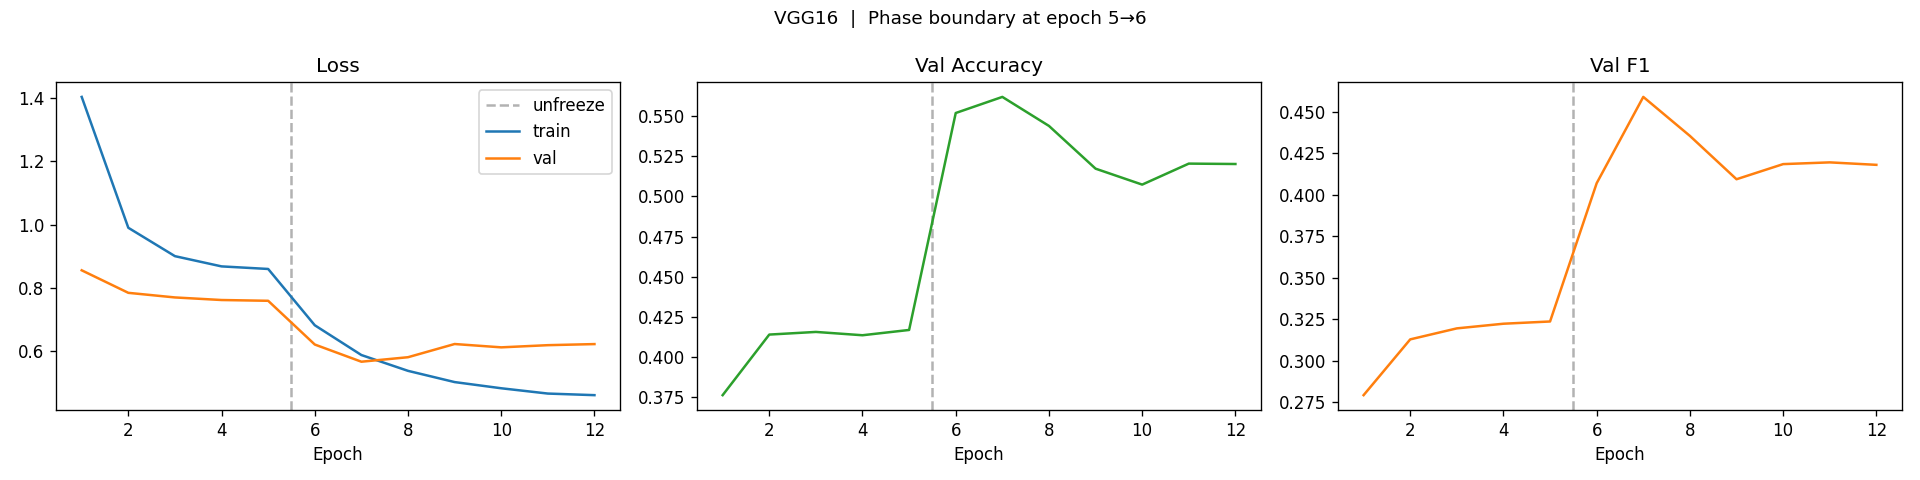


── InceptionV3 — Confusion Matrix ──


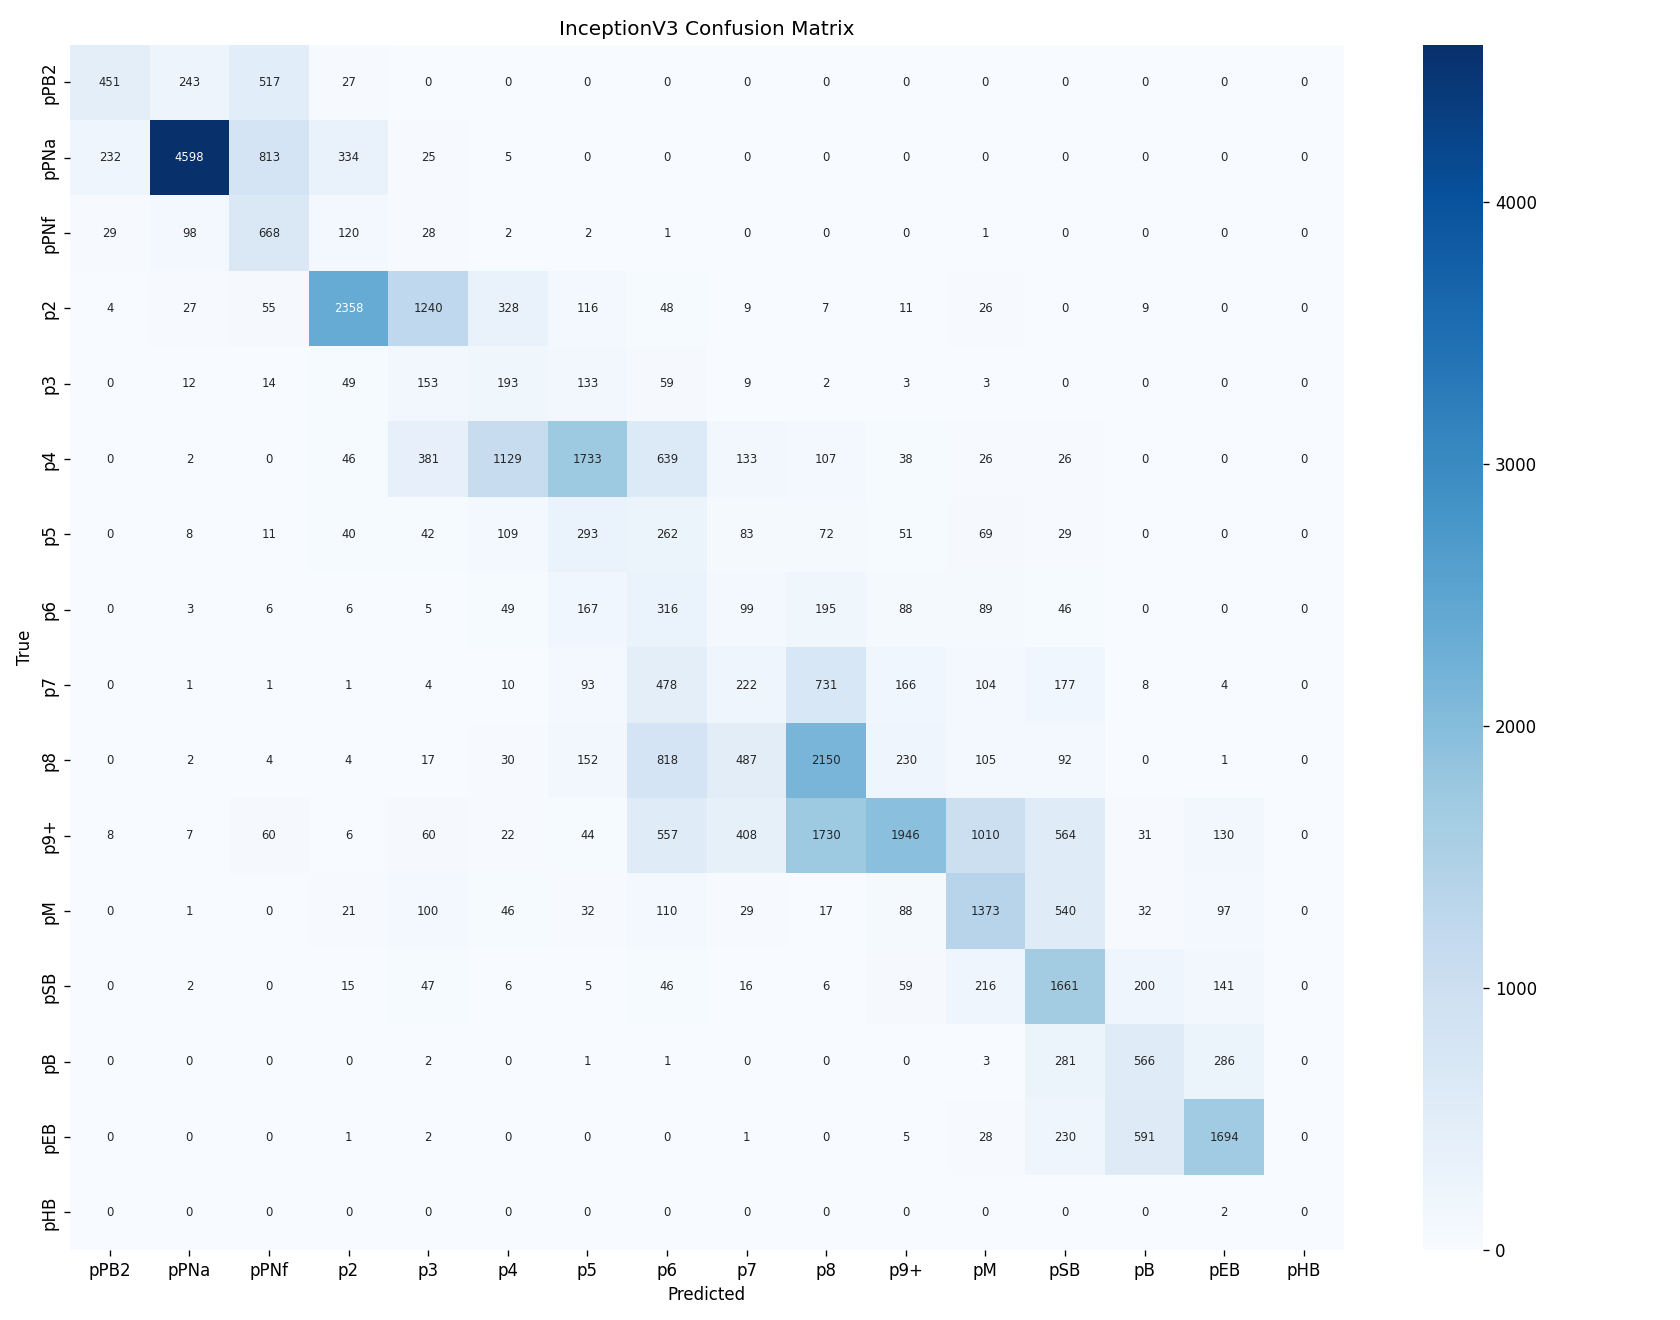


── InceptionV3 — Learning Curves ──


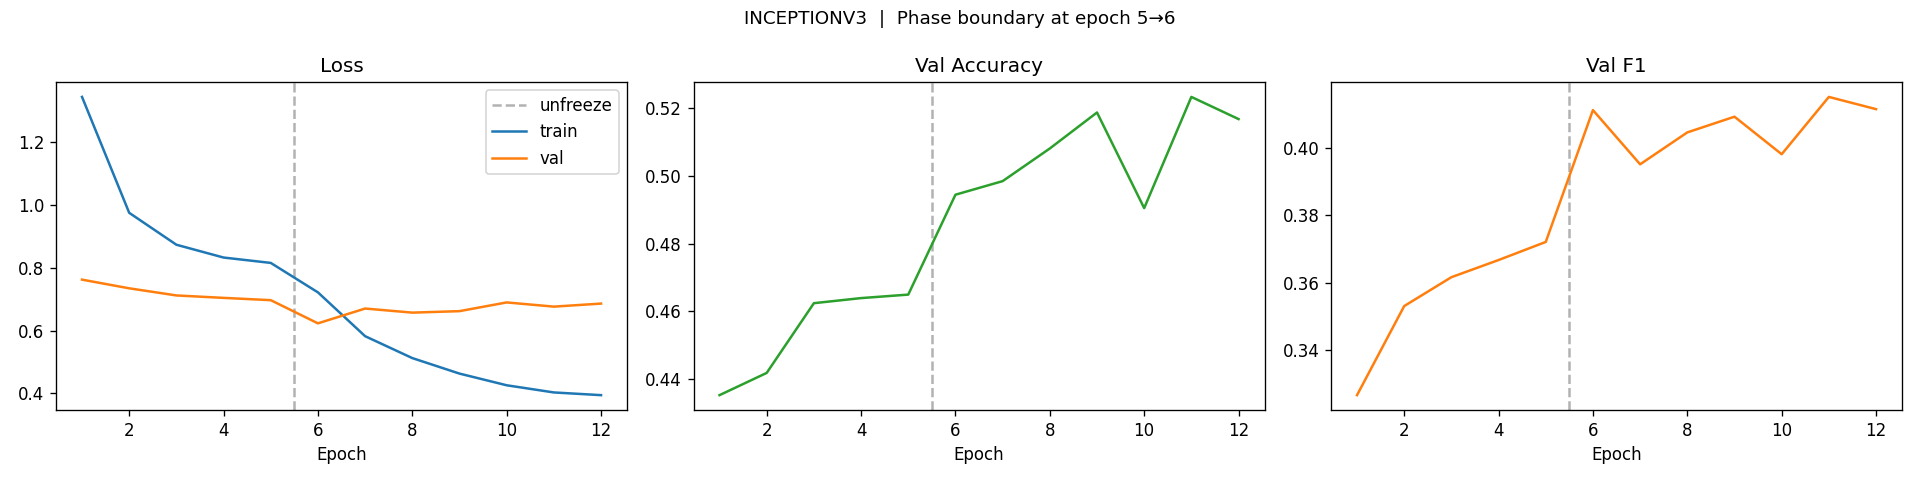

In [20]:
from IPython.display import display, Image

image_files = {
    'Training Curves (All Models)':  OUTPUT_DIR / 'comparison_curves.png',
    'Model Comparison (Bar Chart)':  OUTPUT_DIR / 'model_comparison.png',
}
for name in trained_names:
    image_files[f'{name} — Confusion Matrix'] = OUTPUT_DIR / f'{name}_confusion.png'
    image_files[f'{name} — Learning Curves']  = OUTPUT_DIR / f'{name}_curves.png'

for title, path in image_files.items():
    if path.exists():
        print(f'\n── {title} ──')
        display(Image(str(path)))
    else:
        print(f'[not found] {title}')

In [21]:
print(f"{'Model':<15} {'Total':>12} {'Trainable':>12} {'Non-Trainable':>15}")
print('-' * 57)
for name in trained_names:
    r = results[name]
    # load from checkpoint
    m = keras.models.load_model(
        str(OUTPUT_DIR / f'best_{name}.keras'),
        custom_objects={'OrdinalFocalWeightedLoss': OrdinalFocalWeightedLoss,
                        'CosineAnnealingSchedule': CosineAnnealingSchedule},
        compile=False
    )
    total     = m.count_params()
    trainable = sum(tf.size(w).numpy() for w in m.trainable_weights)
    non_train = total - trainable
    print(f"{name:<15} {total:>12,} {trainable:>12,} {non_train:>15,}")
    del m; gc.collect()

Model                  Total    Trainable   Non-Trainable
---------------------------------------------------------
MobileNetV2        2,950,096    1,897,424       1,052,672
VGG19             20,323,280   17,996,944       2,326,336
VGG16             15,013,584   13,277,328       1,736,256
InceptionV3       22,888,112   13,905,872       8,982,240
